### Sections
| | |
|---|---|
| **A** | Setup — install, imports |
| **B** | Load & explore KG text chunks |
| **C** | Generate base embeddings (baseline) |
| **D** | Build domain Q&A fine-tuning pairs |
| **E** | Fine-tune the embedding model |
| **F** | Evaluate: base vs fine-tuned |
| **G** | Save all artefacts for Notebook 02_02 |

In [57]:
# ── A1: Install required libraries ───────────────────────────────────────────
!pip install -q sentence-transformers torch scikit-learn accelerate
!pip install -q matplotlib seaborn pandas numpy tqdm datasets

In [58]:
# ── A2: Imports ───────────────────────────────────────────────────────────────
import os, sys, json, random, time, warnings
from pathlib import Path
from typing  import List, Tuple, Dict

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Sentence Transformers
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader
import torch

# Scikit-learn
from sklearn.decomposition    import PCA
from sklearn.metrics.pairwise import cosine_similarity

from datasets import Dataset

root = Path.cwd().parent
sys.path.insert(0, str(root))
from config import DATA_DIR

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"   PyTorch version : {torch.__version__}")
print(f"   CUDA available  : {torch.cuda.is_available()}")
print(f"   Device          : {DEVICE}")


   PyTorch version : 2.12.1
   CUDA available  : False
   Device          : cpu


In [59]:
# Path configuration 

DATA_DIR_PRO = DATA_DIR / "processed"
MODEL_DIR    = DATA_DIR / "models"
OUTPUT_DIR   = DATA_DIR / "outputs"

for _d in [DATA_DIR, DATA_DIR_PRO, MODEL_DIR, OUTPUT_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

# ── Key file references ───────────────────────────────────────────────────────
{
    "cell_type": "code",
    "metadata": {
        "language": "python"
    },
    "source": [
        "# Ensure `datasets.Dataset` is available to sentence-transformers internals\n",
        "import datasets\n",
        "import builtins\n",
        "builtins.Dataset = datasets.Dataset\n",
        "print('Patched builtins.Dataset ->', builtins.Dataset)\n"
    ]
},
KG_TEXT_FILE     = DATA_DIR_PRO / "supplychain_kg_text.txt"   # input  (from Phase 1)
FINE_TUNED_MODEL = str(MODEL_DIR / "fine_tuned_embedder")      # output → loaded by 3B
FT_EMBEDDINGS    = OUTPUT_DIR / "ft_embeddings.npy"            # output → loaded by 3B
CHUNK_METADATA   = OUTPUT_DIR / "chunk_metadata.json"          # output → loaded by 3B
BASE_MODEL_NAME  = "all-MiniLM-L6-v2"

print(f"   KG text input   : {KG_TEXT_FILE}")
print(f"   Model output    : {FINE_TUNED_MODEL}")
print(f"   Embeddings out  : {FT_EMBEDDINGS}")
print(f"   Metadata out    : {CHUNK_METADATA}")


   KG text input   : /Users/maheshdhiman/GenerativeAI/supply-chain-optimization-kg/supply-chain-optimization-kg/data/processed/supplychain_kg_text.txt
   Model output    : /Users/maheshdhiman/GenerativeAI/supply-chain-optimization-kg/supply-chain-optimization-kg/data/models/fine_tuned_embedder
   Embeddings out  : /Users/maheshdhiman/GenerativeAI/supply-chain-optimization-kg/supply-chain-optimization-kg/data/outputs/ft_embeddings.npy
   Metadata out    : /Users/maheshdhiman/GenerativeAI/supply-chain-optimization-kg/supply-chain-optimization-kg/data/outputs/chunk_metadata.json


In [60]:
# ── Load KG text chunks produced by notebook 02_03 ───────────────────────
# File format : one natural-language sentence per line, deduplicated, sorted.

def load_kg_chunks(filepath: Path) -> List[str]:
    """Load and basic-validate KG text chunks from a plain-text file."""
    if not filepath.exists():
        raise FileNotFoundError(
            f"\nKG text file not found:\n  {filepath}\n",
            "Please run 02_03_export_kg_triples_as_text.ipynb first,\n",
            "or upload supplychain_kg_text.txt to data/processed/."
        )
    with open(filepath, "r", encoding="utf-8") as f:
        chunks = [line.strip() for line in f if line.strip()]
    if len(chunks) == 0:
        raise ValueError("KG text file is empty. Re-run Phase 1 export notebook.")
    return chunks

chunks = load_kg_chunks(KG_TEXT_FILE)

print(f"   Total chunks : {len(chunks)}")
print(f"   Min length   : {min(len(c) for c in chunks)} chars")
print(f"   Max length   : {max(len(c) for c in chunks)} chars")
print(f"   Avg length   : {sum(len(c) for c in chunks)/len(chunks):.0f} chars")
print("   Sample chunks:")

for c in chunks[:3]:
    print(f"   • {c[:90]}...")


   Total chunks : 1426
   Min length   : 19 chars
   Max length   : 82 chars
   Avg length   : 38 chars
   Sample chunks:
   • Customer 1 has region value West....
   • Customer 1 has tier value 2^^integer....
   • Customer 1 is a Customer....


Chunk distribution:
   entity_type  count  pct
         Order    351 24.6
      Shipment    269 18.9
     Warehouse    234 16.4
       Product    190 13.3
     Inventory    120  8.4
         Route     82  5.8
      Supplier     77  5.4
LogisticsEvent     58  4.1
      Customer     45  3.2


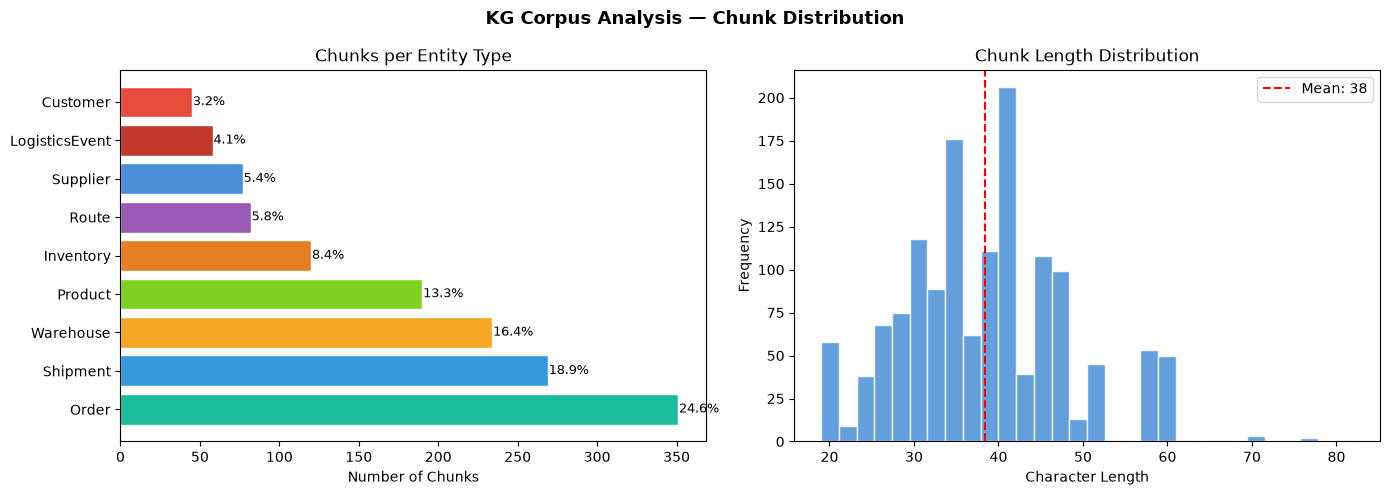

Chart saved → outputs/3a_chunk_distribution.png


In [61]:
# ── Classify chunks by entity type using keyword matching ─────────────────
ENTITY_KEYWORDS: Dict[str, List[str]] = {
    "Supplier"       : ["supplier"],
    "Product"        : ["product"],
    "Warehouse"      : ["warehouse"],
    "Route"          : ["route"],
    "Order"          : ["order"],
    "Shipment"       : ["shipment"],
    "Inventory"      : ["inventory"],
    "Customer"       : ["customer"],
    "LogisticsEvent" : ["event"],
}

ENTITY_COLORS: Dict[str, str] = {
    "Supplier"       : "#4A90D9",
    "Product"        : "#7ED321",
    "Warehouse"      : "#F5A623",
    "Route"          : "#9B59B6",
    "Order"          : "#1ABC9C",
    "Shipment"       : "#3498DB",
    "Inventory"      : "#E67E22",
    "Customer"       : "#E74C3C",
    "LogisticsEvent" : "#C0392B",
    "Other"          : "#95A5A6",
}

def classify_chunk(text: str) -> str:
    """Return entity-type label based on keyword presence (first match wins)."""
    lower = text.lower()
    for entity, keywords in ENTITY_KEYWORDS.items():
        if any(kw in lower for kw in keywords):
            return entity
    return "Other"

chunk_labels: List[str] = [classify_chunk(c) for c in chunks]

# Build metadata dataframe
df_meta = pd.DataFrame({
    "chunk"       : chunks,
    "entity_type" : chunk_labels,
    "char_length" : [len(c) for c in chunks],
})

# Compute distribution and ensure numeric counts
dist = df_meta["entity_type"].value_counts().reset_index()
# normalize columns to known names
if list(dist.columns) == ['index', 'entity_type']:
    dist.columns = ["entity_type", "count"]
else:
    dist = dist.rename(columns={dist.columns[0]: 'entity_type', dist.columns[1]: 'count'})
# Coerce count to numeric (in case of unexpected strings)
dist['count'] = pd.to_numeric(dist['count'], errors='coerce').fillna(0).astype(int)
# Percentage of total chunks
if len(chunks) > 0:
    dist["pct"] = (dist["count"] / len(chunks) * 100).round(1)
else:
    dist["pct"] = 0

print("Chunk distribution:")
print(dist.to_string(index=False))

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("KG Corpus Analysis — Chunk Distribution", fontsize=13, fontweight="bold")

colors = [ENTITY_COLORS.get(e, "#95A5A6") for e in dist["entity_type"]]
axes[0].barh(dist["entity_type"], dist["count"], color=colors, edgecolor="white")
axes[0].set_xlabel("Number of Chunks")
axes[0].set_title("Chunks per Entity Type")
for i, (cnt, pct) in enumerate(zip(dist["count"], dist["pct"])):
    axes[0].text(cnt + 0.5, i, f"{pct}%", va="center", fontsize=9)

axes[1].hist(df_meta["char_length"], bins=30, color="#4A90D9",
             edgecolor="white", alpha=0.85)
axes[1].axvline(df_meta["char_length"].mean(), color="red",
               linestyle="--", label=f'Mean: {df_meta["char_length"].mean():.0f}')
axes[1].set_xlabel("Character Length")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Chunk Length Distribution")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "3a_chunk_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → outputs/3a_chunk_distribution.png")


### Section C — Base Embeddings (Pre-Fine-Tuning Baseline)

In [62]:
# ── Load the base sentence-transformer and encode all KG chunks ───────────
# Model   : all-MiniLM-L6-v2  (384-dimensional, ~80 MB, Apache 2.0)
# Purpose : establish a BASELINE to compare against after fine-tuning
# normalize_embeddings=True  →  L2-normalise vectors
#                            →  cosine_similarity = dot product (faster)
# ─────────────────────────────────────────────────────────────────────────────
print(f"Loading base model: {BASE_MODEL_NAME} ...")
base_model = SentenceTransformer(BASE_MODEL_NAME, device=DEVICE)
print(f" Base model loaded.")
print(f"  Embedding dim   : {base_model.get_sentence_embedding_dimension()}")
print(f"  Max seq length  : {base_model.max_seq_length}")

print(f"\nEncoding {len(chunks)} chunks with base model ...")
t0 = time.time()
base_embeddings = base_model.encode(
    chunks,
    batch_size           = 64,
    show_progress_bar    = True,
    convert_to_numpy     = True,
    normalize_embeddings = True,
)
print(f"\nBase embeddings generated in {time.time()-t0:.1f}s.")
print(f"Shape  : {base_embeddings.shape}")
print(f"Norm   : {np.linalg.norm(base_embeddings[0]):.4f}  (should be ~1.0)")

Loading base model: all-MiniLM-L6-v2 ...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6595.82it/s]


 Base model loaded.
  Embedding dim   : 384
  Max seq length  : 256

Encoding 1426 chunks with base model ...


Batches: 100%|██████████| 23/23 [00:01<00:00, 16.95it/s]


Base embeddings generated in 1.4s.
Shape  : (1426, 384)
Norm   : 1.0000  (should be ~1.0)


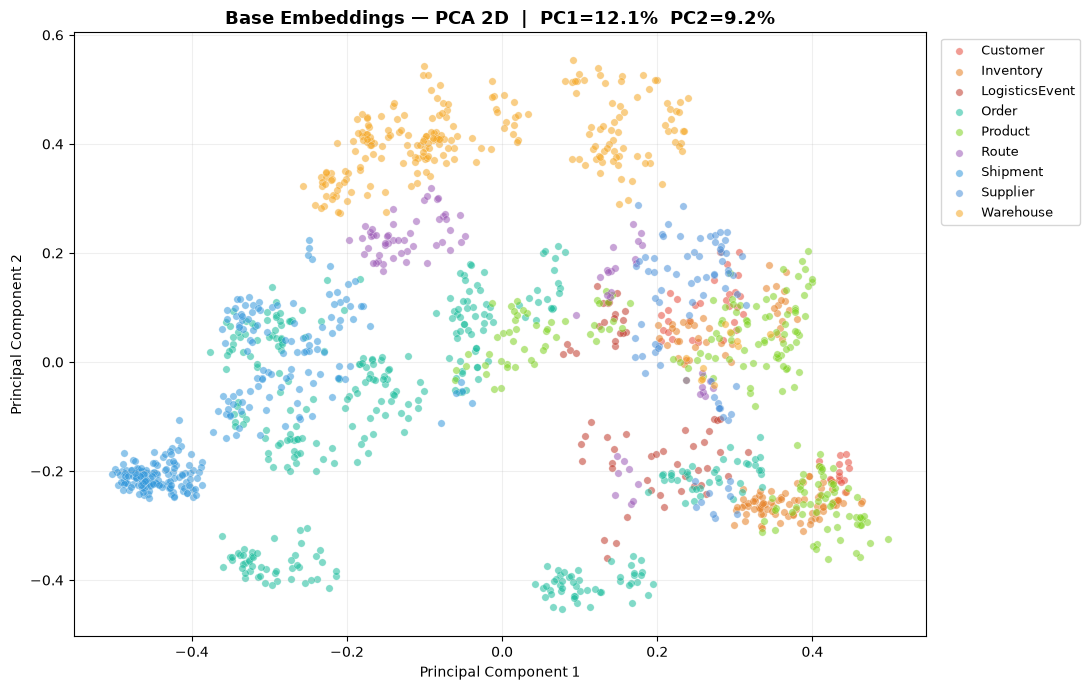

PCA chart saved → outputs/3a_base_pca.png


In [63]:
# ── Visualise Base Embeddings (PCA on base embeddings) ───────────────────
# Reduce 384-dim → 2-dim. Colour by entity type.
# Well-separated clusters indicate the base model already captures
# some domain structure; fine-tuning will tighten these further.
# ─────────────────────────────────────────────────────────────────────────────
pca_base = PCA(n_components=2, random_state=42)
base_2d  = pca_base.fit_transform(base_embeddings)

fig, ax = plt.subplots(figsize=(11, 7))
for entity in sorted(set(chunk_labels)):
    idx   = [i for i, l in enumerate(chunk_labels) if l == entity]
    color = ENTITY_COLORS.get(entity, "#95A5A6")
    ax.scatter(base_2d[idx, 0], base_2d[idx, 1],
               c=color, label=entity, alpha=0.55, s=28,
               edgecolors="white", linewidths=0.3)

var = pca_base.explained_variance_ratio_
ax.set_title(
    f"Base Embeddings — PCA 2D  |  PC1={var[0]*100:.1f}%  PC2={var[1]*100:.1f}%",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "3a_base_pca.png", dpi=150, bbox_inches="tight")
plt.show()
print("PCA chart saved → outputs/3a_base_pca.png")

### Section D — Build Domain Q&A Fine-Tuning Pairs

Create **(query, relevant KG chunk)** pairs.
`MultipleNegativesRankingLoss` pulls query embeddings closer to their matching chunk while pushing them away from all other chunks in the batch.

In [64]:
# ────── Define Query templates per supply chain entity type ─────────────────────────
# Each template is a realistic question a supply chain analyst would ask.
# We pair each template with actual KG chunks of the matching entity type.
# ─────────────────────────────────────────────────────────────────────────────
QUERY_TEMPLATES: Dict[str, List[str]] = {
    "Supplier": [
        "Which suppliers have the highest reliability scores?",
        "Find suppliers with long lead times over 20 days.",
        "Which suppliers are located in a specific country?",
        "List suppliers with low reliability who need review.",
        "Who supplies this product to our supply chain?",
        "What is the average lead time for our suppliers?",
    ],
    "Product": [
        "Which products are critically low on stock?",
        "Find products with high demand levels.",
        "What is the current stock quantity for this product?",
        "Which products need urgent reordering?",
        "Find all products in the Electronics category.",
        "What is the SKU associated with this product?",
    ],
    "Warehouse": [
        "Which warehouse is operating at near full capacity?",
        "Find warehouses with the highest current load.",
        "What is the storage capacity of this warehouse?",
        "Which warehouse locations have available space?",
        "Find underutilised warehouses for redistribution.",
    ],
    "Route": [
        "Which shipping routes have the longest transit times?",
        "Find routes between two specific warehouses.",
        "What is the cost of shipping on this route?",
        "Which routes are the most expensive to use?",
        "Find the fastest available delivery route.",
    ],
    "Order": [
        "Which orders are currently delayed or pending?",
        "Find high priority orders that need immediate attention.",
        "What is the current status of this customer order?",
        "Which orders have been shipped but not delivered?",
        "Find all orders placed by a specific customer.",
    ],
    "Shipment": [
        "Which shipments were delivered after the expected date?",
        "Find all delayed shipments in the current period.",
        "What is the actual delivery date of this shipment?",
        "Which shipments are currently in transit?",
        "Find shipments that arrived late to the warehouse.",
    ],
    "Inventory": [
        "What is the current stock on hand at this warehouse?",
        "Which inventory items are below their reorder point?",
        "Find products with high reserved quantities in inventory.",
        "Which items need to be restocked at the warehouse?",
        "What is the available inventory after reservations?",
    ],
    "Customer": [
        "Find customers located in the North region.",
        "Which customers have the highest service tier?",
        "What region does this customer belong to?",
        "Find all platinum or gold tier customers.",
    ],
    "LogisticsEvent": [
        "What caused the logistics disruption in the supply chain?",
        "Find supply chain events that caused significant delays.",
        "Which supplier was responsible for this logistics event?",
        "What route was affected by this delay or disruption?",
        "Find all high-severity logistics events.",
    ],
}

total_templates = sum(len(v) for v in QUERY_TEMPLATES.values())
print(f"Entity types     : {len(QUERY_TEMPLATES)}")
print(f"Total templates  : {total_templates}")
for k, v in QUERY_TEMPLATES.items():
    print(f"{k:<17}: {len(v)} templates")

Entity types     : 9
Total templates  : 46
Supplier         : 6 templates
Product          : 6 templates
Warehouse        : 5 templates
Route            : 5 templates
Order            : 5 templates
Shipment         : 5 templates
Inventory        : 5 templates
Customer         : 4 templates
LogisticsEvent   : 5 templates


In [65]:
# ── Generate training (query, chunk) positive pairs for fine-tuning ──────────
#   Strategy:
#   1. Group chunk indices by entity type.
#   2. For each entity type, sample chunks and pair each with a query template.
#   3. Shuffle and cap at max_pairs to keep training fast on Colab.
# ─────────────────────────────────────────────────────────────────────────────
def build_training_pairs(
    chunks          : List[str],
    labels          : List[str],
    query_templates : Dict[str, List[str]],
    samples_per_type: int = 20,
    max_pairs       : int = 200,
    seed            : int = 42,
) -> List[Tuple[str, str]]:
    """
    Returns a list of (query, chunk) positive pairs.
    Each chunk is matched with one randomly selected query template
    from its entity type's template list.
    """
    rng = random.Random(seed)

    # Group chunk indices by entity type
    type_to_indices: Dict[str, List[int]] = {}
    for idx, label in enumerate(labels):
        type_to_indices.setdefault(label, []).append(idx)

    pairs: List[Tuple[str, str]] = []
    for entity_type, templates in query_templates.items():
        indices = type_to_indices.get(entity_type, [])
        if not indices or not templates:
            continue
        # Sample chunks for this entity type (with replacement if needed)
        n_sample = min(samples_per_type, len(indices))
        sampled  = rng.sample(indices, n_sample)
        for idx in sampled:
            query = rng.choice(templates)
            pairs.append((query, chunks[idx]))

    rng.shuffle(pairs)
    return pairs[:max_pairs]


train_pairs = build_training_pairs(
    chunks, chunk_labels, QUERY_TEMPLATES,
    samples_per_type = 25,
    max_pairs        = 200,
    seed             = 42,
)

print(f"Training pairs generated: {len(train_pairs)}")
print("\nSample pairs:")
for i, (q, c) in enumerate(train_pairs[:4], 1):
    print(f"\n Pair {i}:")
    print(f"   Query : {q}")
    print(f"   Chunk : {c[:80]}...")

Training pairs generated: 200

Sample pairs:

 Pair 1:
   Query : What is the actual delivery date of this shipment?
   Chunk : Shipment 46 is a Shipment....

 Pair 2:
   Query : Find products with high demand levels.
   Chunk : Order 40 has product Product 1....

 Pair 3:
   Query : What is the available inventory after reservations?
   Chunk : Inventory 8 has stockOnHand value 14^^integer....

 Pair 4:
   Query : Which warehouse locations have available space?
   Chunk : Inventory 1 has warehouse Warehouse 4....


In [66]:
# ── Wrap pairs in InputExample objects and create a PyTorch DataLoader ────
# InputExample(texts=[anchor, positive]) is the sentence-transformers
# standard format for MultipleNegativesRankingLoss.
# drop_last=True  ensures every batch has the same size, which the loss
# function requires for stable in-batch negative construction.
# ─────────────────────────────────────────────────────────────────────────────
BATCH_SIZE = 16   # safe for Colab T4 free tier

train_examples = [
    InputExample(texts=[query, chunk])
    for query, chunk in train_pairs
]

train_dataloader = DataLoader(
    train_examples,
    shuffle    = True,
    batch_size = BATCH_SIZE,
    drop_last  = True,
)

print(f"Total pairs      : {len(train_examples)}")
print(f"Batch size       : {BATCH_SIZE}")
print(f"Batches/epoch    : {len(train_dataloader)}")
print(f"Effective pairs  : {len(train_dataloader) * BATCH_SIZE}")

Total pairs      : 200
Batch size       : 16
Batches/epoch    : 12
Effective pairs  : 192


### Section E — Fine-Tune the Embedding Model

In [67]:
# ── Fine-tune all-MiniLM-L6-v2 with MultipleNegativesRankingLoss ──────────
#
# MultipleNegativesRankingLoss (MNRL):
#   • Given a batch of (query_i, doc_i) pairs:
#   • Maximises cosine similarity between query_i and its matching doc_i
#   • Minimises cosine similarity between query_i and all OTHER docs in batch
#   • No explicit negative examples needed — negatives are in-batch
#   • Highly effective for retrieval / semantic search tasks
# ─────────────────────────────────────────────────────────────────────────────

NUM_EPOCHS   = 4
WARMUP_RATIO = 0.1   # 10% of total steps for learning-rate warmup

ft_model   = SentenceTransformer(BASE_MODEL_NAME, device=DEVICE)
train_loss = losses.MultipleNegativesRankingLoss(model=ft_model)

total_steps  = len(train_dataloader) * NUM_EPOCHS
warmup_steps = max(1, int(total_steps * WARMUP_RATIO))

print(f"Starting fine-tuning ...")
print(f"   Base model   : {BASE_MODEL_NAME}")
print(f"   Epochs       : {NUM_EPOCHS}")
print(f"   Total steps  : {total_steps}")
print(f"   Warmup steps : {warmup_steps}")
print(f"   Device       : {DEVICE}")
print()

t0 = time.time()
ft_model.fit(
    train_objectives  = [(train_dataloader, train_loss)],
    epochs            = NUM_EPOCHS,
    warmup_steps      = warmup_steps,
    output_path       = FINE_TUNED_MODEL,
    show_progress_bar = True,
)
elapsed = time.time() - t0

print(f"Fine-tuning complete")
print(f"Time elapsed   : {elapsed:.0f}s  ({elapsed/60:.1f} min)")
print(f"Model saved to : {FINE_TUNED_MODEL}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10136.64it/s]


Starting fine-tuning ...
   Base model   : all-MiniLM-L6-v2
   Epochs       : 4
   Total steps  : 48
   Warmup steps : 4
   Device       : cpu



Step,Training Loss


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 12.32it/s]

Fine-tuning complete
Time elapsed   : 11s  (0.2 min)
Model saved to : /Users/maheshdhiman/GenerativeAI/supply-chain-optimization-kg/supply-chain-optimization-kg/data/models/fine_tuned_embedder


In [68]:
# ── Load Fine-Tuned Model & Generate Embeddings ─────────────────────────- 
# Reload the saved model and encode all chunks 
# Loading from disk (not using the in-memory ft_model) verifies that the
# save/load cycle works correctly — important for the 3B handoff.
# ─────────────────────────────────────────────────────────────────────────

ft_model = SentenceTransformer(FINE_TUNED_MODEL, device=DEVICE)
print(f"Fine-tuned model loaded from: {FINE_TUNED_MODEL}")
print(f"Embedding dim : {ft_model.get_sentence_embedding_dimension()}")

print(f"\nEncoding {len(chunks)} chunks with fine-tuned model ...")
t0 = time.time()
ft_embeddings = ft_model.encode(
    chunks,
    batch_size           = 64,
    show_progress_bar    = True,
    convert_to_numpy     = True,
    normalize_embeddings = True,
)
print(f"\nFine-tuned embeddings generated in {time.time()-t0:.1f}s.")
print(f"Shape : {ft_embeddings.shape}")
print(f"Norm  : {np.linalg.norm(ft_embeddings[0]):.4f}  (should be ~1.0)")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7987.53it/s]


Fine-tuned model loaded from: /Users/maheshdhiman/GenerativeAI/supply-chain-optimization-kg/supply-chain-optimization-kg/data/models/fine_tuned_embedder
Embedding dim : 384

Encoding 1426 chunks with fine-tuned model ...


Batches: 100%|██████████| 23/23 [00:01<00:00, 15.11it/s]


Fine-tuned embeddings generated in 1.5s.
Shape : (1426, 384)
Norm  : 1.0000  (should be ~1.0)


### Section F - Evaluate: Base vs Fine-Tuned

For each of 5 held-out business queries we compare how many of the top-5 retrieved chunks belong to the **expected entity type** (Hits@5), and what the top-1 cosine similarity score is.

In [69]:
# ── Held-out evaluation queries (not used in fine-tuning) ─────────────────
EVAL_QUERIES: List[Dict] = [
    {
        "query"       : "Which suppliers have high reliability scores?",
        "expected_kw" : "supplier",
        "label"       : "Supplier",
    },
    {
        "query"       : "Find warehouses that are nearly at full capacity.",
        "expected_kw" : "warehouse",
        "label"       : "Warehouse",
    },
    {
        "query"       : "Which shipments were delivered after the expected date?",
        "expected_kw" : "shipment",
        "label"       : "Shipment",
    },
    {
        "query"       : "Which products are low on stock and need urgent reordering?",
        "expected_kw" : "product",
        "label"       : "Product",
    },
    {
        "query"       : "Find logistics events that caused major supply chain delays.",
        "expected_kw" : "event",
        "label"       : "LogisticsEvent",
    },
]
print(f"{len(EVAL_QUERIES)} evaluation queries defined.")

5 evaluation queries defined.


In [70]:
# ── Run COmparison - Retrieve top-5 chunks for each query from both models ─────────────────
def retrieve_top_k(
    query      : str,
    embeddings : np.ndarray,
    model      : SentenceTransformer,
    k          : int = 5,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Embed query and retrieve top-k chunks by cosine similarity.
    Both the corpus embeddings and query must be L2-normalised
    (normalize_embeddings=True) so dot product = cosine similarity.
    """
    q_emb = model.encode(
        [query],
        convert_to_numpy     = True,
        normalize_embeddings = True,
    )
    sims     = cosine_similarity(q_emb, embeddings)[0]  # shape (n_chunks,)
    top_k    = np.argsort(sims)[::-1][:k]
    return top_k, sims[top_k]

comparison_rows = []

print("=" * 68)
print("  BASE vs FINE-TUNED — RETRIEVAL COMPARISON")
print("=" * 68)

for eq in EVAL_QUERIES:
    query   = eq["query"]
    exp_kw  = eq["expected_kw"]
    label   = eq["label"]

    base_idx, base_sims = retrieve_top_k(query, base_embeddings, base_model)
    ft_idx,   ft_sims   = retrieve_top_k(query, ft_embeddings,   ft_model)

    base_hits = sum(1 for i in base_idx if exp_kw in chunks[i].lower())
    ft_hits   = sum(1 for i in ft_idx   if exp_kw in chunks[i].lower())

    print(f"\n{label} | \"{query}\"")
    print(f"Base model  — Hits@5: {base_hits}/5  top-1 sim: {base_sims[0]:.4f}")
    print(f"Fine-tuned  — Hits@5: {ft_hits}/5   top-1 sim: {ft_sims[0]:.4f}")
    print(f"Best result (fine-tuned): {chunks[ft_idx[0]][:75]}...")

    comparison_rows.append({
        "Entity Type"     : label,
        "Base Hits@5"     : base_hits,
        "FT Hits@5"       : ft_hits,
        "Base Top-1 Sim"  : round(float(base_sims[0]), 4),
        "FT Top-1 Sim"    : round(float(ft_sims[0]),   4),
        "Δ Sim"           : round(float(ft_sims[0] - base_sims[0]), 4),
    })

df_comparison = pd.DataFrame(comparison_rows)
print("\n" + "=" * 68)
print("  SUMMARY")
print("=" * 68)
print(df_comparison.to_string(index=False))

  BASE vs FINE-TUNED — RETRIEVAL COMPARISON

Supplier | "Which suppliers have high reliability scores?"
Base model  — Hits@5: 5/5  top-1 sim: 0.7389
Fine-tuned  — Hits@5: 5/5   top-1 sim: 0.7623
Best result (fine-tuned): Supplier 9 has reliability score 7.55^^float....

Warehouse | "Find warehouses that are nearly at full capacity."
Base model  — Hits@5: 5/5  top-1 sim: 0.5942
Fine-tuned  — Hits@5: 5/5   top-1 sim: 0.5677
Best result (fine-tuned): Warehouse 1 has capacity value 986^^integer....

Shipment | "Which shipments were delivered after the expected date?"
Base model  — Hits@5: 5/5  top-1 sim: 0.6463
Fine-tuned  — Hits@5: 5/5   top-1 sim: 0.6716
Best result (fine-tuned): Shipment 16 has expectedDeliveryDate value 2023-04-13^^date....

Product | "Which products are low on stock and need urgent reordering?"
Base model  — Hits@5: 5/5  top-1 sim: 0.4637
Fine-tuned  — Hits@5: 5/5   top-1 sim: 0.5831
Best result (fine-tuned): Order 4 has product Product 10....

LogisticsEvent | "Find 

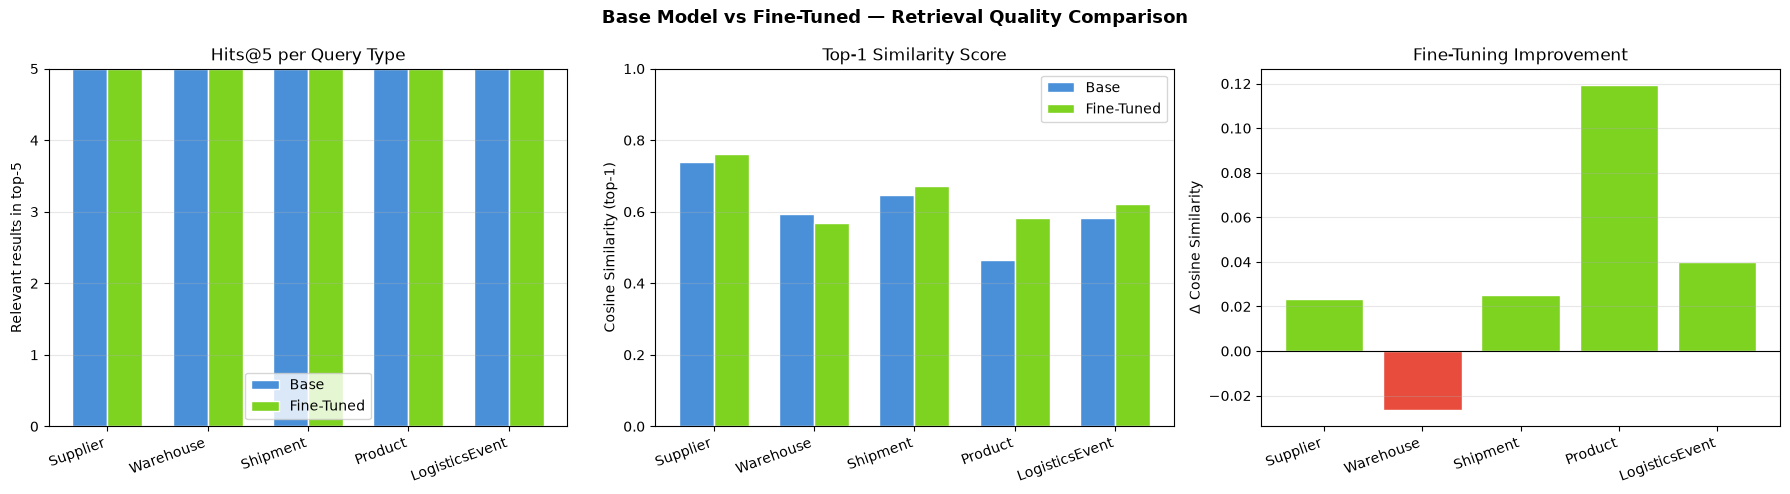

Comparison chart saved → outputs/3a_comparison.png


In [71]:
# ───────────────────── Visual Comparison ────────────────────
# Side-by-side charts — base vs fine-tuned retrieval quality
# ────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Base Model vs Fine-Tuned — Retrieval Quality Comparison",
             fontsize=13, fontweight="bold")

x = np.arange(len(df_comparison))
w = 0.35
labels_x = df_comparison["Entity Type"]

# Left: Hits@5
axes[0].bar(x - w/2, df_comparison["Base Hits@5"], w,
            label="Base",       color="#4A90D9", edgecolor="white")
axes[0].bar(x + w/2, df_comparison["FT Hits@5"],  w,
            label="Fine-Tuned", color="#7ED321", edgecolor="white")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_x, rotation=20, ha="right")
axes[0].set_ylabel("Relevant results in top-5")
axes[0].set_title("Hits@5 per Query Type")
axes[0].set_ylim(0, 5)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Middle: Top-1 cosine similarity
axes[1].bar(x - w/2, df_comparison["Base Top-1 Sim"], w,
            label="Base",       color="#4A90D9", edgecolor="white")
axes[1].bar(x + w/2, df_comparison["FT Top-1 Sim"],   w,
            label="Fine-Tuned", color="#7ED321", edgecolor="white")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_x, rotation=20, ha="right")
axes[1].set_ylabel("Cosine Similarity (top-1)")
axes[1].set_title("Top-1 Similarity Score")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

# Right: improvement (Δ similarity)
delta_colors = ["#7ED321" if d >= 0 else "#E74C3C" for d in df_comparison["Δ Sim"]]
axes[2].bar(x, df_comparison["Δ Sim"], color=delta_colors, edgecolor="white")
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels_x, rotation=20, ha="right")
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_ylabel("Δ Cosine Similarity")
axes[2].set_title("Fine-Tuning Improvement")
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "3a_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Comparison chart saved → outputs/3a_comparison.png")

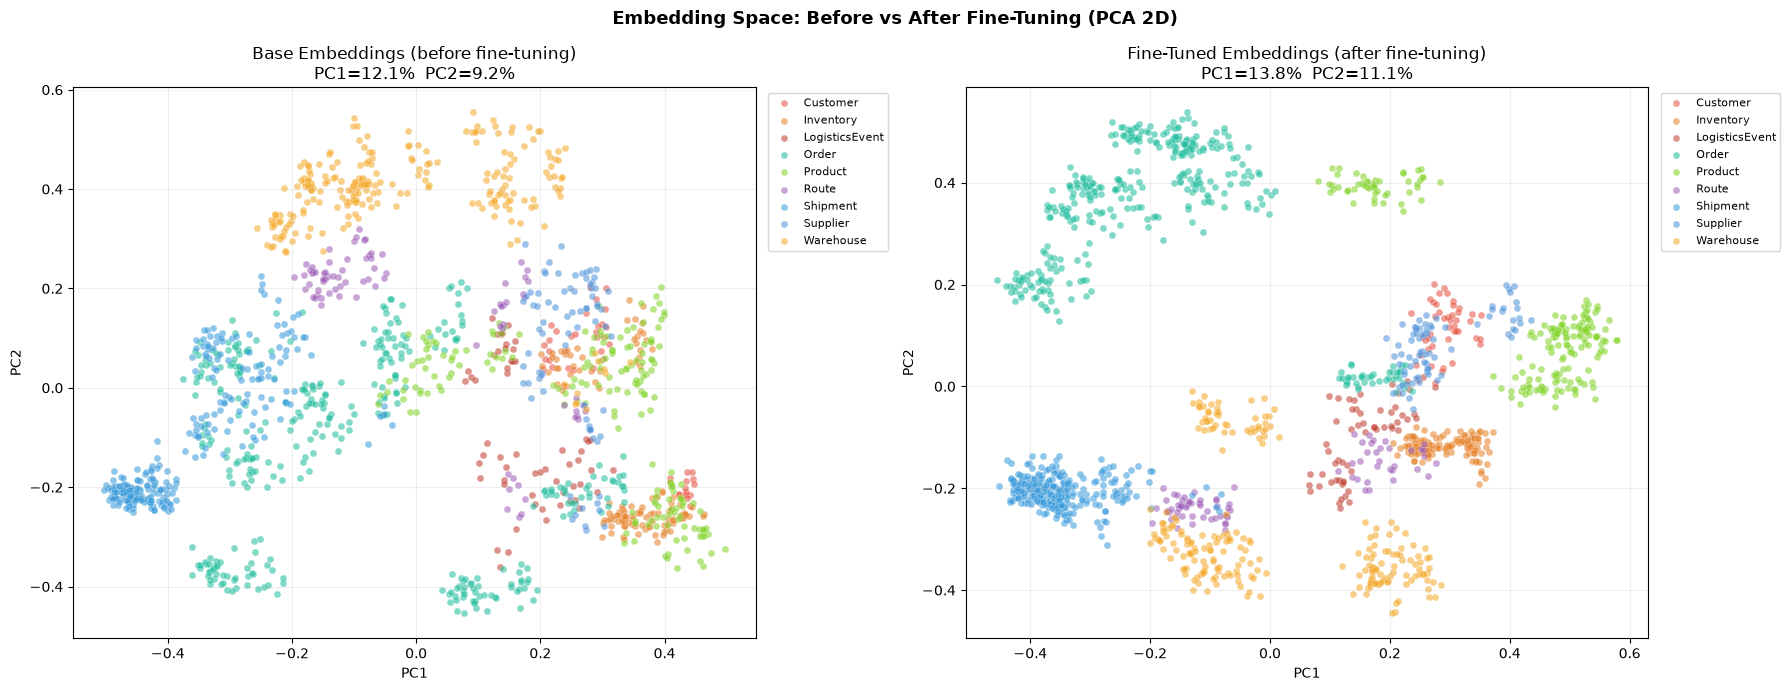

PCA comparison saved → outputs/3a_pca_comparison.png


In [72]:
# ── PCA of fine-tuned embeddings — compare cluster separation with C2 ─────
pca_ft = PCA(n_components=2, random_state=42)
ft_2d  = pca_ft.fit_transform(ft_embeddings)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Embedding Space: Before vs After Fine-Tuning (PCA 2D)",
             fontsize=13, fontweight="bold")

for ax, emb_2d, pca_obj, title in [
    (axes[0], base_2d, pca_base, "Base Embeddings (before fine-tuning)"),
    (axes[1], ft_2d,  pca_ft,   "Fine-Tuned Embeddings (after fine-tuning)"),
]:
    for entity in sorted(set(chunk_labels)):
        idx   = [i for i, l in enumerate(chunk_labels) if l == entity]
        color = ENTITY_COLORS.get(entity, "#95A5A6")
        ax.scatter(emb_2d[idx, 0], emb_2d[idx, 1],
                   c=color, label=entity, alpha=0.55, s=25,
                   edgecolors="white", linewidths=0.3)
    var = pca_obj.explained_variance_ratio_
    ax.set_title(f"{title}\nPC1={var[0]*100:.1f}%  PC2={var[1]*100:.1f}%")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "3a_pca_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("PCA comparison saved → outputs/3a_pca_comparison.png")

### Section G - Save Artefacts for Notebook 02-02

Three files are written to disk. Notebook 02_02 loads all three at startup — no re-training or re-encoding needed.

In [73]:
# ── Save fine-tuned embeddings and chunk metadata ─────────────────────────
#
# Artefact 1 — ft_embeddings.npy
#   NumPy array of shape (n_chunks, 384), L2-normalised.
#   3B loads this directly — avoids re-encoding 1 413 chunks.
#
# Artefact 2 — chunk_metadata.json
#   List of dicts: {chunk, entity_type, char_length}.
#   3B uses this to populate ChromaDB metadata and recover chunk text.
#
# Artefact 3 — fine_tuned_embedder/ (already saved by model.fit())
#   Full sentence-transformer model directory.
#   3B loads this to embed new queries at search time.
# ─────────────────────────────────────────────────────────────────────────────

# 1. Save embeddings array
np.save(FT_EMBEDDINGS, ft_embeddings)
print(f"Embeddings saved   → {FT_EMBEDDINGS}")
print(f"Shape  : {ft_embeddings.shape}")
print(f"Size   : {FT_EMBEDDINGS.stat().st_size / 1024:.0f} KB")

# 2. Save chunk metadata
metadata_records = [
    {
        "chunk"       : chunks[i],
        "entity_type" : chunk_labels[i],
        "char_length" : len(chunks[i]),
    }
    for i in range(len(chunks))
]
with open(CHUNK_METADATA, "w", encoding="utf-8") as f:
    json.dump(metadata_records, f, ensure_ascii=False, indent=2)
print(f"\nChunk metadata saved → {CHUNK_METADATA}")
print(f"Records : {len(metadata_records)}")

# 3. Confirm fine-tuned model directory exists
ft_model_path = Path(FINE_TUNED_MODEL)
model_files   = list(ft_model_path.glob("*")) if ft_model_path.exists() else []
print(f"\nFine-tuned model  → {FINE_TUNED_MODEL}")
print(f"Files   : {[f.name for f in model_files]}")

# ── Final summary ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  NOTEBOOK 3A COMPLETE — Ready for 3B")
print("=" * 60)
print("\n  Artefacts for Notebook 3B:")
print(f"  {FINE_TUNED_MODEL}")
print(f"  {FT_EMBEDDINGS}")
print(f"  {CHUNK_METADATA}")
print("\n  Next: Open 03b_chromadb_semantic_search.ipynb")
print("=" * 60)

Embeddings saved   → /Users/maheshdhiman/GenerativeAI/supply-chain-optimization-kg/supply-chain-optimization-kg/data/outputs/ft_embeddings.npy
Shape  : (1426, 384)
Size   : 2139 KB

Chunk metadata saved → /Users/maheshdhiman/GenerativeAI/supply-chain-optimization-kg/supply-chain-optimization-kg/data/outputs/chunk_metadata.json
Records : 1426

Fine-tuned model  → /Users/maheshdhiman/GenerativeAI/supply-chain-optimization-kg/supply-chain-optimization-kg/data/models/fine_tuned_embedder
Files   : ['model.safetensors', '2_Normalize', '1_Pooling', 'tokenizer_config.json', 'config.json', 'config_sentence_transformers.json', 'tokenizer.json', 'README.md', 'sentence_bert_config.json', 'modules.json']

  NOTEBOOK 3A COMPLETE — Ready for 3B

  Artefacts for Notebook 3B:
  /Users/maheshdhiman/GenerativeAI/supply-chain-optimization-kg/supply-chain-optimization-kg/data/models/fine_tuned_embedder
  /Users/maheshdhiman/GenerativeAI/supply-chain-optimization-kg/supply-chain-optimization-kg/data/outputs